# Project Title
### Student Performance Predictor



# Description of the Project

 This project focuses on developing a machine learning model that predicts student academic performance based on various factors, including past academic records, attendance, engagement in coursework, and demographic information. The system will be able to identify students who may require additional support, tailor educational interventions, and ultimately improve student success rates and retention.

# Libraries Used

## Pandas :
The pandas library is one of the most essential tools in Python for data analysis and manipulation.

## Sklearn :

sklearn stands for Scikit-learn, which is one of the most popular Python libraries for machine learning.
It provides easy-to-use tools for:

*   Building models
*   Preprocessing data
*   Splitting datasets
*   Evaluating performance

### 1. 'model_selection' Module

model_selection is a module inside sklearn.
It contains tools that help you prepare and evaluate your model, such as:

*   Splitting data into training/testing sets
*   Cross-validation
*   Hyperparameter tuning

### 2. 'LinearRegression' Module

LinearRegression is a machine learning model that assumes a straight-line (linear) relationship between the input features and the output (target).

In our case:

*   Inputs (X_train) might include things like attendance, previous scores, internet access, etc.
*   Output (y_train) is the final exam score.

The model tries to learn the best-fit line (like y = mx + c) that can predict the final exam score based on all those features.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error

# Import Dataset
When working with a machine learning project, we first need to get the data into Python so we can analyze and use it.

This usually means you have a data file — like a .csv (Comma-Separated Values) file — saved on your computer or in Google Colab.

In our case, the file is :

"Student Performance Predictor.csv"



In [ ]:
df = pd.read_csv('/content/Student Performance Predictor.csv')

NameError: name 'pd' is not defined

# Read Dataset :

df.head() ->  Shows the first 5 rows of your dataset by default.

It gives you a quick preview of:

1. Column names

2. Data values

3. Data types (numeric, text, etc.)

In [ ]:
df.head()

NameError: name 'df' is not defined



---



***df.info()*** -> Displays basic information about your DataFrame:

1. Column names

2. Number of non-null (filled) values

3. Data types (int, float, object, etc.)

4. Total memory usage

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gender                        1000 non-null   object 
 1   age                           1000 non-null   int64  
 2   parental_education            1000 non-null   object 
 3   family_income                 1000 non-null   float64
 4   internet_access               1000 non-null   object 
 5   previous_exam_score           1000 non-null   float64
 6   attendance_rate               1000 non-null   float64
 7   homework_completion_rate      1000 non-null   float64
 8   class_participation_score     1000 non-null   float64
 9   number_of_absences            1000 non-null   int64  
 10  extra_curricular_involvement  628 non-null    object 
 11  learning_hours_per_week       1000 non-null   float64
 12  tutor_support                 1000 non-null   object 
 13  fina



---



***df.describe()*** -> Gives you statistical summaries of all numeric columns:

1. Mean

2. Standard deviation

3. Minimum & maximum values

4. 25%, 50%, and 75% percentiles

In [ ]:
df.describe()

,age,family_income,previous_exam_score,attendance_rate,homework_completion_rate,class_participation_score,number_of_absences,learning_hours_per_week,final_exam_score
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,16.496000,40053.207840,69.92909,80.429630,74.312590,4.923780,1.979000,9.984440,76.024760
std,1.697901,9800.512538,14.30842,11.550007,14.572686,2.909478,1.448674,3.084464,11.214959
min,14.000000,14302.140000,30.00000,60.050000,50.040000,0.030000,0.000000,0.350000,39.840000
25%,15.000000,33566.487500,60.36750,70.547500,61.272500,2.325000,1.000000,7.955000,68.060000
50%,17.000000,40566.090000,69.93500,80.985000,74.265000,4.935000,2.000000,9.955000,76.270000
75%,18.000000,46650.012500,80.00750,90.380000,86.965000,7.425000,3.000000,12.080000,84.180000
max,19.000000,77007.250000,100.00000,99.990000,99.990000,9.990000,8.000000,21.170000,100.000000




---



# Initial Gathered Information ( Raw Data ) :

1. There are total 14 columns.

2. There are 1000 entries in total.

3. The dtypes are : float64 (7) ,  int64 (2) ,  object (5)

4. There are some missing data in the column name 'extra_curricular_involvement'.


# Drop the entries with missing values

dropna() is a method in pandas that allows you to remove missing values (also called NaN = Not a Number) from your DataFrame.

In [ ]:
df = df.dropna()

In [ ]:
# Now check the newly updated dataframe afterdropping the missing values

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 628 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gender                        628 non-null    object 
 1   age                           628 non-null    int64  
 2   parental_education            628 non-null    object 
 3   family_income                 628 non-null    float64
 4   internet_access               628 non-null    object 
 5   previous_exam_score           628 non-null    float64
 6   attendance_rate               628 non-null    float64
 7   homework_completion_rate      628 non-null    float64
 8   class_participation_score     628 non-null    float64
 9   number_of_absences            628 non-null    int64  
 10  extra_curricular_involvement  628 non-null    object 
 11  learning_hours_per_week       628 non-null    float64
 12  tutor_support                 628 non-null    object 
 13  final_exam



---



# "object" DTYPE Issue

In our dataset, some columns have the data type object. That usually means they contain text or categorical data like:


*   'male' / 'female' (gender)
*   'yes' / 'no' (internet access)
*   'high school', 'bachelor', etc. (parental education)


## Problem :

Machine Learning models can’t understand text directly.
They need numbers to perform calculations.

## Solution :

We can encode the data. Change the text into numerals ( for example, 0, 1, 2, etc).



---

## Column "gender" :

Its dtype is object. The values " Female" and "Male" are texts.

So, we replace "Female" with 1 and "Male" with 0.


In [ ]:
df['gender'].value_counts()

,count
gender,
Female,316
Male,312


In [ ]:
# Changing 'Female' with 1 and 'Male' with 0

df['gender'] = df['gender'].replace({'Female':1, 'Male':0})

/tmp/ipython-input-290494318.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'] = df['gender'].replace({'Female':1, 'Male':0})


In [ ]:
# The resultant

df['gender'].value_counts()

,count
gender,
1,316
0,312




---

## Column 'parental_education' :

Its dtype is object. The values 'Diploma', 'Graduate', 'High School', 'Postgraduate' are texts.

So, we replace 'Diploma' with 0, 'Graduate' with 2, 'High School' with 1, and 'Postgraduate' with 3.

In [ ]:
df['parental_education'].value_counts()

,count
parental_education,
Diploma,198
Graduate,182
High School,181
Postgraduate,67


In [ ]:
# Changing the 'Diploma' with 0, 'Graduate' with 2, 'High School' with 1, and 'Postgraduate' with 3

df['parental_education'] = df['parental_education'].replace({'Diploma':0,'High School':1,
                                  'Graduate':2,'Postgraduate':3})

/tmp/ipython-input-1134271620.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['parental_education'] = df['parental_education'].replace({'Diploma':0,'High School':1,


In [ ]:
# The resultant

df['parental_education'].value_counts()

,count
parental_education,
0,198
2,182
1,181
3,67




---

## Column 'internet_access' :

Its dtype is object. The values 'Yes' and 'No' are texts.

So, we replace 'Yes' with 1 and 'No' with 0.

In [ ]:
df['internet_access'].value_counts()

,count
internet_access,
Yes,543
No,85


In [ ]:
# Changing the 'Yes' with 1 and 'No' with 0

df['internet_access'] = df['internet_access'].replace({'Yes':1, 'No':0})

/tmp/ipython-input-279239275.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['internet_access'] = df['internet_access'].replace({'Yes':1, 'No':0})


In [ ]:
# The resultant

df['internet_access'].value_counts()

,count
internet_access,
1,543
0,85




---

## Column 'tutor_support' :

Its dtype is object. The values 'Yes' and 'No' are in texts.

So, we replace 'Yes' with 1 and 'No' with 0.

In [ ]:
df['tutor_support'].value_counts()

,count
tutor_support,
Yes,348
No,280


In [ ]:
# Changing the 'Yes' with 1 and 'No' with 0.

df['tutor_support'] = df['tutor_support'].replace({'Yes':1, 'No':0})

/tmp/ipython-input-3961136738.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['tutor_support'] = df['tutor_support'].replace({'Yes':1, 'No':0})


In [ ]:
# The resultant

df['tutor_support'].value_counts()

,count
tutor_support,
1,348
0,280




---

## Column 'extra_curricular_involvement' :

Its dtype is object. The values 'Low', 'Moderate', 'High' are in texts.

So, we replace 'Low' with 0, 'Moderate' with 1, and 'High' with 2.



In [ ]:
df['extra_curricular_involvement'].value_counts()

,count
extra_curricular_involvement,
Low,311
Moderate,224
High,93


In [ ]:
# Changing the 'Low' with 0, 'Moderate' with 1, and 'High' with 2.

df['extra_curricular_involvement'] = df['extra_curricular_involvement'].replace({'Low':0,'Moderate':1,'High':2})

/tmp/ipython-input-3912024153.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['extra_curricular_involvement'] = df['extra_curricular_involvement'].replace({'Low':0,'Moderate':1,'High':2})


In [ ]:
# The resulatant

df['extra_curricular_involvement'].value_counts()

,count
extra_curricular_involvement,
0,311
1,224
2,93




---

## Now checking the processed data :

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 628 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gender                        628 non-null    int64  
 1   age                           628 non-null    int64  
 2   parental_education            628 non-null    int64  
 3   family_income                 628 non-null    float64
 4   internet_access               628 non-null    int64  
 5   previous_exam_score           628 non-null    float64
 6   attendance_rate               628 non-null    float64
 7   homework_completion_rate      628 non-null    float64
 8   class_participation_score     628 non-null    float64
 9   number_of_absences            628 non-null    int64  
 10  extra_curricular_involvement  628 non-null    int64  
 11  learning_hours_per_week       628 non-null    float64
 12  tutor_support                 628 non-null    int64  
 13  final_exam

In [ ]:
df.columns

Index(['gender', 'age', 'parental_education', 'family_income',
       'internet_access', 'previous_exam_score', 'attendance_rate',
       'homework_completion_rate', 'class_participation_score',
       'number_of_absences', 'extra_curricular_involvement',
       'learning_hours_per_week', 'tutor_support', 'final_exam_score'],
      dtype='object')



---



# Defining the X and the Y

In machine learning, we need to split our dataset into:

1.   Features (X) – the input data we use to make predictions
2.   Target (y) – the actual outcome we want to predict

## X -> Features

All columns except the one we want to predict:

*   'gender'
*   'age'
*   'parental_education'
*   'family_income'
*   'internet_access'
*   'previous_exam_score
*   'attendance_rate'
*   'homework_completion_rate'
*   'class_participation_score'
*   'number_of_absences'
*   'extra_curricular_involvement'
*   'learning_hours_per_week'
*   'tutor_support'

## Y -> Target

The column we want to predict:

*   'final_exam_score'

In [ ]:
y = df['final_exam_score']
X = df[['gender', 'age', 'parental_education', 'family_income',
       'internet_access', 'previous_exam_score', 'attendance_rate',
       'homework_completion_rate', 'class_participation_score',
       'number_of_absences', 'extra_curricular_involvement',
       'learning_hours_per_week', 'tutor_support']]

NameError: name 'df' is not defined



---



# Train-Test Split :

It’s a function that helps you divide your dataset into two parts:

*   Training set (X_train, y_train) – used to teach the model

*   Test set (X_test, y_test) – used to evaluate how well the model performs on unseen data.



## Why do we split the data?

If you trained and tested on the same data:

*   The model would memorize the answers (overfitting)

*   You wouldn’t know how well it performs on new data

So we split the dataset to simulate real-world predictions.

### What is 'random_state' ?

It  ensures the same random split every time (for consistency).
We can use any number for the random_state. Here, I have used 16 .

### In what ratio does the data splits as train and test data?

The default split is 75% training data and 25% testing data. But, if we want to do it in some other ratio, we can specify the ratio in our code as :



*   X_train, X_test, y_train, y_test = train_test_split, y, test_size=0.2, random_state=16)

OR

*   X_train, X_test, y_train, y_test = train_test_split, y, train_size=0.2, random_state=16) .


Here, we have taken the default split.


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=16)



---

## Prediction Type :

Because we are trying to predict a continuous numerical value 'final_exam_score' , it is a regression problem.

A regression problem is when the output (target variable y) is a real number, like:

*   marks
*   prices
*   temperatures
*   house sizes

Not categories like "pass/fail", "yes/no", "A/B/C" .

## Why use Linear Regression (and not another regression model)?

Linear Regression is a good first choice when:

*   You want a simple, interpretable model
*   You assume the relationship between features and target is roughly linear
(i.e., as features increase/decrease, the target also increases/decreases in a straight-line pattern).


## Creating an empty model object :

Since our problem is a Linear Regression type, we have imported 'LinearRegression' module from Scikit-learn library and created an empty object called 'model'.

The model hasn’t learned anything yet — it’s just ready to be trained.


In [ ]:
model = LinearRegression()



---

## Train the Model:

Now, since we have created the model named 'model', ( which is still empty but ready to train ) , we train the model with our testing data which we had earlier created using Train-Test Split.

Now the model:

*   Learns the relationship between the features and the target
*   Finds coefficients (weights) for each input feature
*   Is ready to make predictions using .predict() .



In [ ]:
model.fit(X_train,y_train)

LinearRegression()



---

# Predict :

At this point, our model has been trained.

### .predict(X_test) :

This tells the model:

"Use what you've learned during training and predict the final exam scores for these test students (i.e., the rows in X_test)."

### 'y_pred' :

We store those predictions in a variable called 'y_pred' .



In [ ]:
y_pred = model.predict(X_test)



---

# Evaluation :

Now, we need to evaluate our model on the basis of the training data we have given to it, and the testing data it has been tested on.

For this, we are using RMSE ( root_mean_sqaure_error ) .

## What is root_mean_sqaure_error?

This is a performance metric for regression models. It tells you:

“how well a regression line fits the data points”.
It is a common metric used in machine learning to measure the difference between predicted and actual values in a regression model.

It’s also written as: RMSE.

## What does the function do?

It compares:

*   y_test = the actual final exam scores (true answers)
*   y_pred = the predicted scores from your model

And gives you how far off the predictions are, in percentage terms.

### Formula for RMSE:

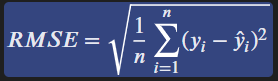


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(rmse)

5.381958731734552




---



# Results :

We have got a RMSE (Root Mean Square Error) of 5.38%.

It means, our model’s predictions are, on average, only 5.38% away from the actual exam scores.




---


# Conclusion :


In this project, we developed a linear regression model to predict students' final exam scores using data set. The dataset was first explored, cleaned, and preprocessed by encoding categorical features and scaling numerical ones. After splitting the data into training and testing sets, we trained the model using Scikit-learn’s `LinearRegression`. The model demonstrated strong performance with a root mean square error of just 5.38%, indicating high accuracy. This predictive tool can help students needing academic support and enhance personalized learning strategies.





